## Step 1: Setup and Imports
Import the core Python libraries used for data processing, numerical analysis, and visualization.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'monospace'
plt.rcParams['font.monospace'] = ['Cascadia Code', 'Consolas', 'Courier New']

## Step 2: Load Dataset
Read the Amazon sales dataset into a pandas DataFrame for analysis.

In [2]:
df = pd.read_csv('amazon_sales_dataset.csv')

## Step 3: Check Data Shape
Inspect the number of rows and columns to understand dataset size.

In [3]:
df.shape

(50000, 13)

## Step 4: Preview Records
Display the first few rows to validate structure and sample values.

In [4]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


## Step 5: Inspect Schema
Review column names, data types, and non-null counts.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          50000 non-null  int64  
 1   order_date        50000 non-null  str    
 2   product_id        50000 non-null  int64  
 3   product_category  50000 non-null  str    
 4   price             50000 non-null  float64
 5   discount_percent  50000 non-null  int64  
 6   quantity_sold     50000 non-null  int64  
 7   customer_region   50000 non-null  str    
 8   payment_method    50000 non-null  str    
 9   rating            50000 non-null  float64
 10  review_count      50000 non-null  int64  
 11  discounted_price  50000 non-null  float64
 12  total_revenue     50000 non-null  float64
dtypes: float64(4), int64(5), str(4)
memory usage: 5.0 MB


## Step 6: Explore Category Values
Inspect unique product categories to understand class distribution.

In [6]:
df['product_category'].unique()

<StringArray>
['Books', 'Fashion', 'Sports', 'Beauty', 'Electronics', 'Home & Kitchen']
Length: 6, dtype: str

## Step 7: Parse Date Column
Convert `order_date` to datetime for time-based feature engineering.

In [7]:
df['order_date'] = pd.to_datetime(df['order_date'])

## Step 8: Create Calendar Features
Extract year, month, and day from the order date.

In [8]:
df['year'] = df['order_date'].dt.year
df['month'] = df['order_date'].dt.month
df['day'] = df['order_date'].dt.day

## Step 9: Review Updated Data
Check the DataFrame after adding temporal features.

In [9]:
df.head()

,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,4,13
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,3,12
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,9,28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,4,17
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,3,13


## Step 10: Revenue Sanity Check
Compute sample revenue using discounted price and quantity sold.

In [ ]:
(df["discounted_price"] * df["quantity_sold"]).head()


0     463.52
1    1210.40
2     793.28
3    1264.64
4     806.72
dtype: float64

## Step 11: Verify Stored Revenue and Correlations
Compare computed values with stored revenue and prepare correlation-based insights.

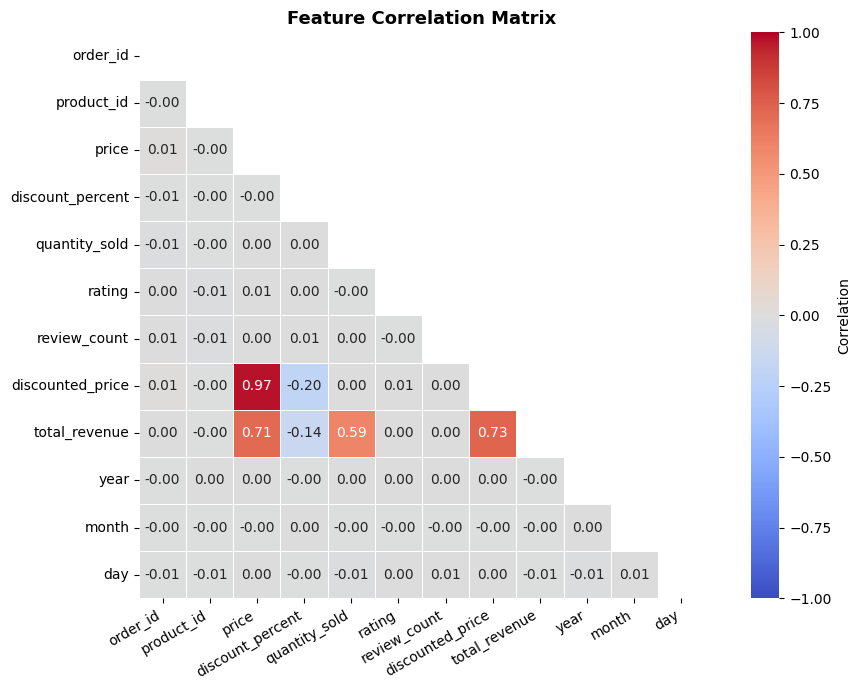

In [ ]:
df["total_revenue"].head()
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle (redundant)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, linewidths=0.5, square=True,
            vmin=-1, vmax=1, cbar_kws={"label": "Correlation"})
plt.title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 12: Validate Revenue Formula
Confirm that `total_revenue` is consistent with price and quantity calculations.

In [12]:
((df["discounted_price"] * df["quantity_sold"]).round(2) == df["total_revenue"].round(2)).all()

np.True_

## Step 13: Build Product-Region Pivot
Aggregate total revenue by product category and customer region.

In [13]:
product_region = df.pivot_table(
    values="total_revenue",
    index="product_category",
    columns="customer_region",
    aggfunc="sum"
)

product_region

customer_region,Asia,Europe,Middle East,North America
product_category,,,,
Beauty,1401916.92,1358226.42,1387711.96,1402769.67
Books,1391961.69,1330671.45,1428560.07,1333669.82
Electronics,1319074.46,1407118.94,1379642.77,1364757.86
Fashion,1334485.23,1366107.00,1390228.60,1389302.51
Home & Kitchen,1369676.45,1326424.56,1375546.52,1401485.02
Sports,1358085.08,1323763.20,1340154.58,1385232.96


## Step 14: Visualize Product vs Region Revenue
Use a heatmap to highlight category-region revenue patterns.

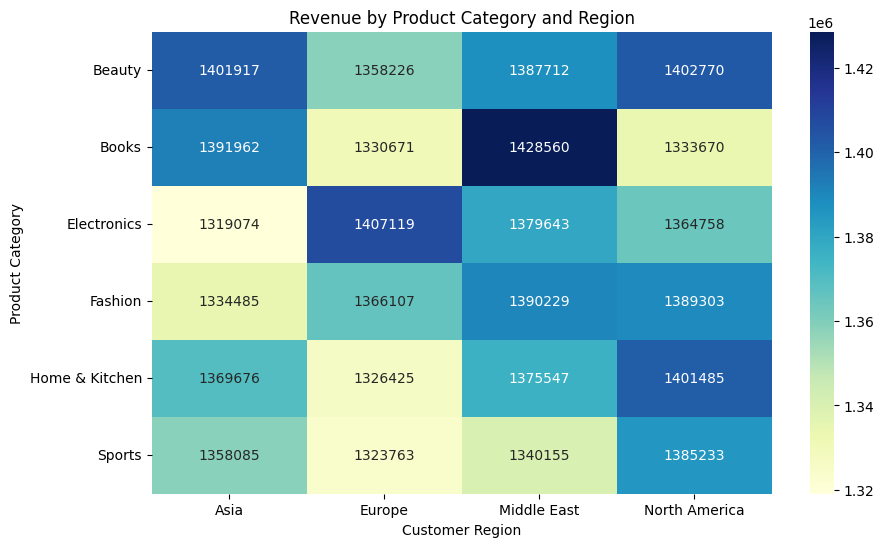

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(product_region, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Revenue by Product Category and Region")
plt.ylabel("Product Category")
plt.xlabel("Customer Region")

plt.show()

## Step 15: Compute Category Revenue Ranking
Summarize total revenue by product category in descending order.

In [15]:
product_revenue = df.groupby("product_category")["total_revenue"].sum().sort_values(ascending=False)

## Step 16: Build Comparative Revenue Charts
Visualize category performance using bar and pie chart comparisons.

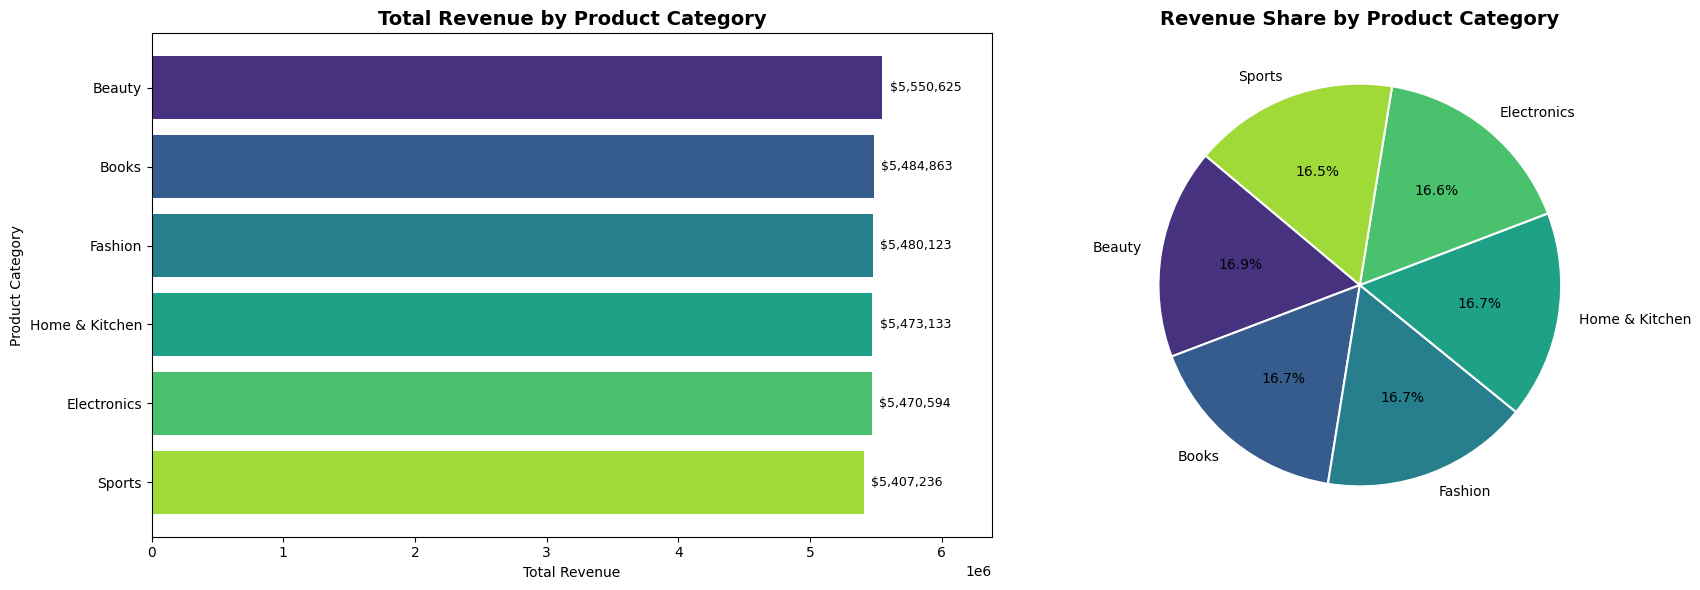

In [ ]:

fig, axes = plt.subplots(1, 2, figsize=(18, 6))


colors = sns.color_palette("viridis", len(product_revenue))
bars = axes[0].barh(product_revenue.index, product_revenue.values, color=colors)
axes[0].set_title("Total Revenue by Product Category", fontsize=14, fontweight='bold')
axes[0].set_xlabel("Total Revenue")
axes[0].set_ylabel("Product Category")
axes[0].invert_yaxis()
for bar, val in zip(bars, product_revenue.values):
    axes[0].text(val + product_revenue.values.max() * 0.01, bar.get_y() + bar.get_height() / 2,
                 f"${val:,.0f}", va='center', fontsize=9)
axes[0].set_xlim(0, product_revenue.values.max() * 1.15)


wedge_props = {'edgecolor': 'white', 'linewidth': 1.5}
axes[1].pie(
    product_revenue.values,
    labels=product_revenue.index,
    autopct='%1.1f%%',
    colors=sns.color_palette("viridis", len(product_revenue)),
    wedgeprops=wedge_props,
    startangle=140
)
axes[1].set_title("Revenue Share by Product Category", fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


## Step 17: Analyze Product Category by Payment Method
Create a pivot-based heatmap to compare payment behavior across product categories.

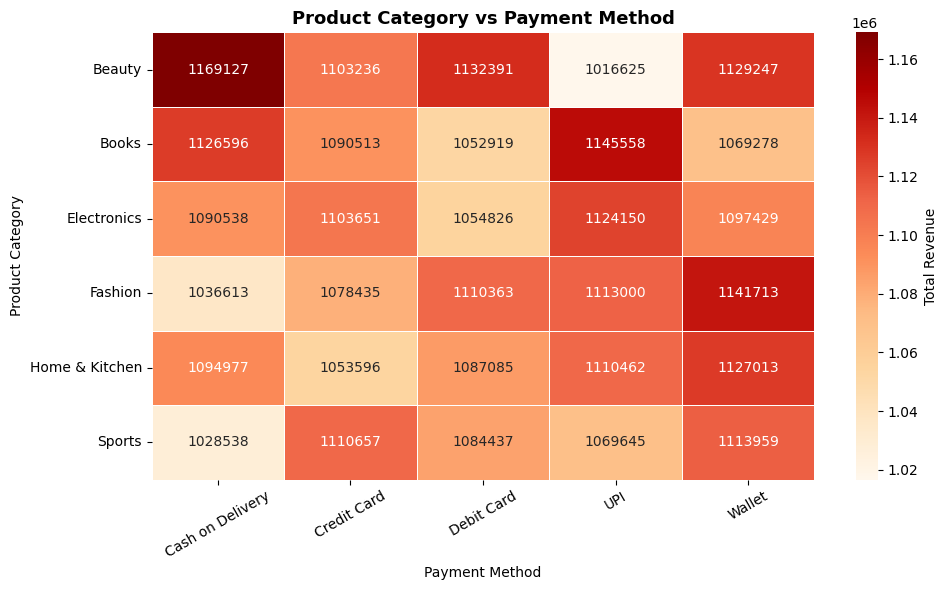

In [17]:
pivot2 = df.pivot_table(values="total_revenue", index="product_category",
                        columns="payment_method", aggfunc="sum")

plt.figure(figsize=(10, 6))
sns.heatmap(pivot2, annot=True, fmt=".0f", cmap="OrRd",
            linewidths=0.5, cbar_kws={"label": "Total Revenue"})
plt.title("Product Category vs Payment Method", fontsize=13, fontweight='bold')
plt.xlabel("Payment Method")
plt.ylabel("Product Category")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Step 18: Analyze Region by Payment Method
Evaluate total revenue patterns across regions and payment methods.

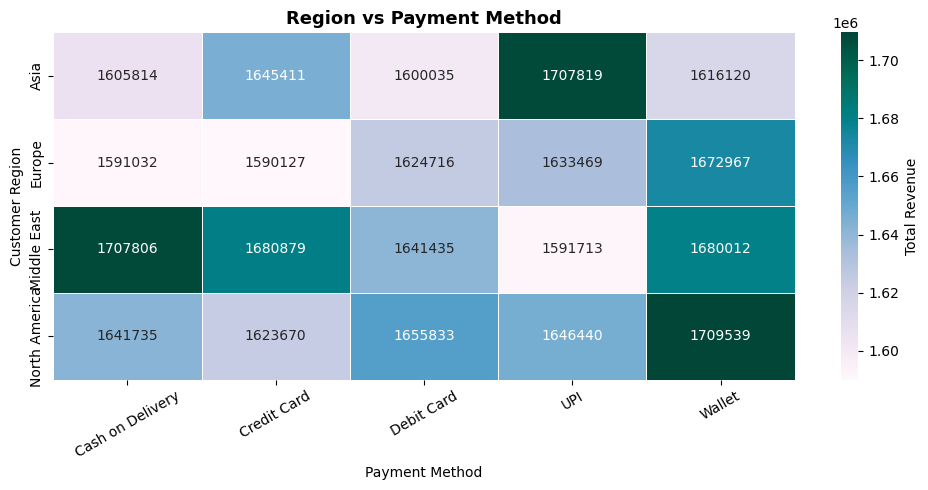

In [18]:

pivot_region_payment = df.pivot_table(values="total_revenue", index="customer_region",
                                      columns="payment_method", aggfunc="sum")

plt.figure(figsize=(10, 5))
sns.heatmap(pivot_region_payment, annot=True, fmt=".0f", cmap="PuBuGn",
            linewidths=0.5, cbar_kws={"label": "Total Revenue"})
plt.title("Region vs Payment Method", fontsize=13, fontweight='bold')
plt.xlabel("Payment Method")
plt.ylabel("Customer Region")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


## Step 19: Explore Discount vs Quantity Relationship
Use a scatter plot to inspect the relationship between discount and quantity sold.

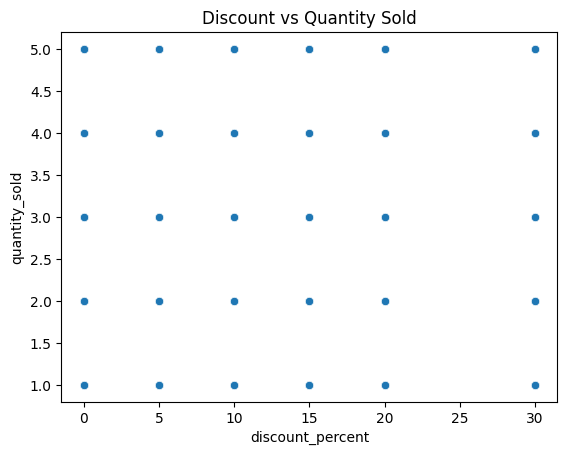

In [19]:
sns.scatterplot(x="discount_percent", y="quantity_sold", data=df)
plt.title("Discount vs Quantity Sold")
plt.show()

## Step 20: Explore Rating vs Quantity Relationship
Check whether product ratings are associated with unit sales volume.

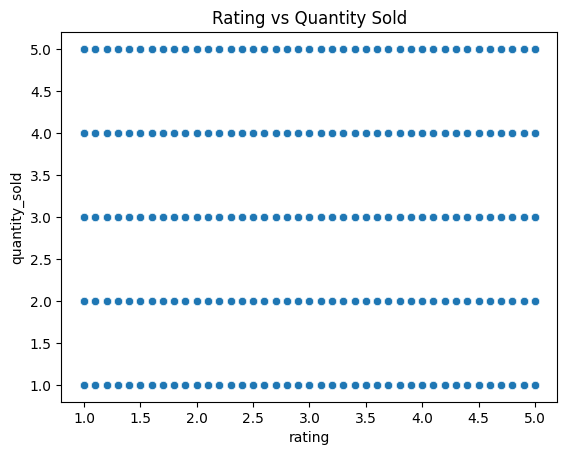

In [20]:
sns.scatterplot(x="rating", y="quantity_sold", data=df)
plt.title("Rating vs Quantity Sold")
plt.show()

## Step 21: Analyze Reviews vs Revenue
Visualize how review volume relates to total revenue.

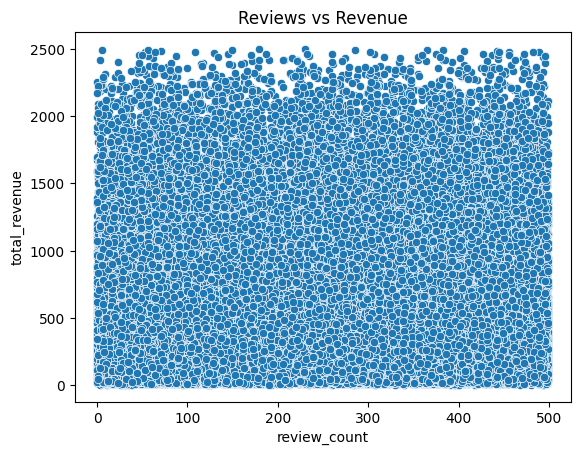

In [21]:
sns.scatterplot(x="review_count", y="total_revenue", data=df)
plt.title("Reviews vs Revenue")
plt.show()

## Step 22: Recheck Correlation Matrix
Recompute and visualize correlations after exploratory additions.

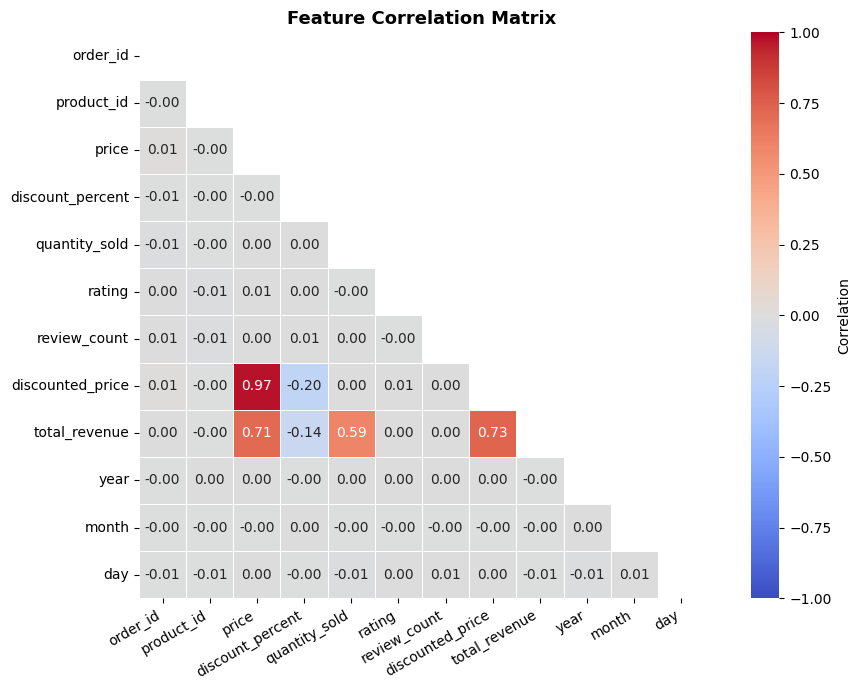

In [22]:

corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))   # hide upper triangle (redundant)
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            mask=mask, linewidths=0.5, square=True,
            vmin=-1, vmax=1, cbar_kws={"label": "Correlation"})
plt.title("Feature Correlation Matrix", fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


## Step 23: Build Modeling Dataset
Create a model-focused table by removing identifier and date fields.

In [23]:
df_model = df.drop(columns=["order_id","product_id","order_date"])

## Step 24: Preview Modeling Dataset
Inspect the transformed dataset before encoding features.

In [24]:
df_model.head()

,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day
0,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,4,13
1,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,3,12
2,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,9,28
3,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,4,17
4,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,3,13


## Step 25: Encode Product Category
Convert `product_category` into numeric category codes.

In [25]:
df_model['product_category'] = df_model['product_category'].astype('category').cat.codes

## Step 26: Preview Encoded Category Field
Review the dataset after encoding `product_category`.

In [26]:
df_model.head()

,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day
0,1,128.75,10,4,North America,UPI,3.5,443,115.88,463.52,2022,4,13
1,3,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40,2023,3,12
2,5,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28,2022,9,28
3,1,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64,2022,4,17
4,0,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72,2022,3,13


## Step 27: Encode Payment Method
Convert `payment_method` into numeric category codes.

In [27]:
df_model['payment_method'] = df_model['payment_method'].astype('category').cat.codes

## Step 28: Preview Payment Encoding Results
Validate the DataFrame after encoding payment categories.

In [28]:
df_model.head()

,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day
0,1,128.75,10,4,North America,3,3.5,443,115.88,463.52,2022,4,13
1,3,302.60,20,5,Asia,1,3.7,475,242.08,1210.40,2023,3,12
2,5,495.80,20,2,Europe,3,4.4,183,396.64,793.28,2022,9,28
3,1,371.95,15,4,Middle East,3,5.0,212,316.16,1264.64,2022,4,17
4,0,201.68,0,4,Middle East,3,4.6,308,201.68,806.72,2022,3,13


## Step 29: Encode Customer Region
Convert `customer_region` into numeric category codes for classification.

In [29]:
df_model['customer_region'] = df_model['customer_region'].astype('category').cat.codes

## Step 30: Inspect Encoded Dataset Schema
Confirm final data types and structure before modeling.

In [ ]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   product_category  50000 non-null  int8   
 1   price             50000 non-null  float64
 2   discount_percent  50000 non-null  int64  
 3   quantity_sold     50000 non-null  int64  
 4   customer_region   50000 non-null  int8   
 5   payment_method    50000 non-null  int8   
 6   rating            50000 non-null  float64
 7   review_count      50000 non-null  int64  
 8   discounted_price  50000 non-null  float64
 9   total_revenue     50000 non-null  float64
 10  year              50000 non-null  int32  
 11  month             50000 non-null  int32  
 12  day               50000 non-null  int32  
dtypes: float64(4), int32(3), int64(3), int8(3)
memory usage: 3.4 MB


## Step 31: Preview Encoded Dataset
Review the prepared modeling table before feature selection.

In [31]:
df_model.head()

,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue,year,month,day
0,1,128.75,10,4,3,3,3.5,443,115.88,463.52,2022,4,13
1,3,302.60,20,5,0,1,3.7,475,242.08,1210.40,2023,3,12
2,5,495.80,20,2,1,3,4.4,183,396.64,793.28,2022,9,28
3,1,371.95,15,4,2,3,5.0,212,316.16,1264.64,2022,4,17
4,0,201.68,0,4,2,3,4.6,308,201.68,806.72,2022,3,13


## Step 32: Define Features and Target
Build `X` and `y` for customer region classification.

In [32]:
X = df_model[[
    "product_category",
    "price",
    "discount_percent",
    "payment_method",
    "rating",
    "review_count",
    "discounted_price",
    "month"
]]

y = df_model["customer_region"]

## Step 33: Split Training and Test Sets
Partition data for model training and out-of-sample evaluation.

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Step 34: Train Random Forest Model
Initialize and fit a Random Forest classifier on training data.

In [34]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

## Step 35: Evaluate with Accuracy
Generate predictions and compute overall accuracy on test data.

In [35]:
from sklearn.metrics import accuracy_score

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.2453


## Step 36: Prepare Classification Metrics
Import evaluation utilities for detailed model diagnostics.

In [36]:
from sklearn.metrics import classification_report

## Step 37: Generate Test Predictions
Run inference on the test set to produce predicted labels.

In [37]:
y_pred = model.predict(X_test)

## Step 38: Print Classification Report
Review precision, recall, F1-score, and support by class.

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.25      0.27      0.26      2460
           1       0.25      0.25      0.25      2494
           2       0.26      0.24      0.25      2595
           3       0.23      0.23      0.23      2451

    accuracy                           0.25     10000
   macro avg       0.25      0.25      0.25     10000
weighted avg       0.25      0.25      0.25     10000

